<a href="https://colab.research.google.com/github/joshuammelcrak-art/Estocasticos/blob/main/Matriz_Fundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matriz Fundamental

## <font color="#0B5394">Serpientes y escaleras </font>

## <font color="#0B5394">Simulación </font>

### Objetivo

Estimar el número promedio de tiradas necesarias para terminar
una partida del juego Serpientes y Escaleras mediante simulación
Monte Carlo utilizando Python.

### Descripción del problema

El juego Serpientes y Escaleras consiste en avanzar sobre un
tablero de 20 casillas mediante tiradas de un dado.

El tablero utilizado contiene:
- una escalera que conecta la casilla 3 con la 18,
- una serpiente que conecta la casilla 13 con la 4,
- una serpiente que conecta la casilla 17 con la 9.

El objetivo consiste en estimar el número promedio de tiradas
necesarias para llegar a la casilla final.

In [40]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Representación del tablero

El tablero se modeló mediante un diccionario en Python.

- La llave representa la casilla inicial.
- El valor representa la casilla destino.

Por ejemplo:
- 3:18 representa una escalera.
- 13:4 representa una serpiente.

In [41]:
tablero = {

    # Escaleras
    3: 11,
    15: 19,

    # Serpientes
    13: 4,
    17: 10
}

### Algoritmo de simulación

La simulación de una partida sigue los siguientes pasos:

1. El jugador inicia en la casilla 0.
2. En cada turno se genera una tirada aleatoria entre 1 y 6.
3. El jugador avanza el número de casillas correspondiente.
4. Si el jugador cae en una serpiente o escalera,
   cambia automáticamente de posición.
5. El juego termina cuando el jugador llega exactamente
   a la casilla 20.
6. Se registra el número total de tiradas utilizadas.

In [42]:
def jugar_partida():

    posicion = 0
    tiradas = 0

    while posicion < 20:

        dado = random.randint(1, 6)

        tiradas += 1

        nueva_posicion = posicion + dado

        # Si el jugador se pasa de 20,
        # permanece en la misma casilla
        if nueva_posicion <= 20:
            posicion = nueva_posicion

        # Verificar serpientes o escaleras
        if posicion in tablero:
            posicion = tablero[posicion]

    return tiradas

### Método Monte Carlo

Para aproximar el valor esperado del número de tiradas,
se repitió la simulación una gran cantidad de veces.

En este trabajo se realizaron 100000 simulaciones
independientes del juego.

In [43]:
numero_simulaciones = 100000

resultados = []

for _ in range(numero_simulaciones):

    tiradas = jugar_partida()

    resultados.append(tiradas)

promedio = np.mean(resultados)

print("Número de simulaciones:", numero_simulaciones)
print("Promedio de tiradas:", round(promedio, 4))

print("\nInformación adicional")
print("Mínimo de tiradas:", np.min(resultados))
print("Máximo de tiradas:", np.max(resultados))
print("Desviación estándar:", round(np.std(resultados), 4))

Número de simulaciones: 100000
Promedio de tiradas: 11.623

Información adicional
Mínimo de tiradas: 3
Máximo de tiradas: 74
Desviación estándar: 6.4214


### Visualización de resultados

Para analizar el comportamiento de las simulaciones,
se construyó un histograma con la distribución del número
de tiradas obtenidas.

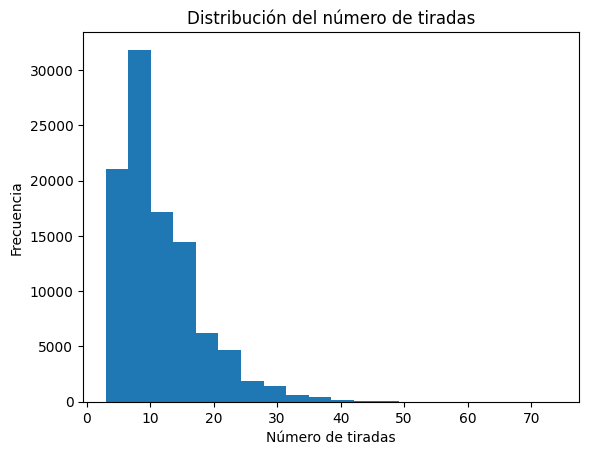

In [44]:
plt.hist(resultados, bins=20)

plt.xlabel("Número de tiradas")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de tiradas")

plt.show()

### Resultados

Después de realizar las simulaciones correspondientes,
se obtuvo un valor aproximado para el número promedio
de tiradas necesarias para terminar el juego.

El resultado puede variar ligeramente en cada ejecución,
debido a la naturaleza aleatoria de la simulación.

### Conclusión

La simulación Monte Carlo permitió aproximar el número
esperado de tiradas necesarias para finalizar una partida
del juego Serpientes yEscaleras.

El uso de simulaciones computacionales resulta útil para
analizar sistemas probabilísticos donde obtener una solución
exacta puede ser complicado de manera analítica.

## <font color="#0B5394"> Analíticamente </font>

El juego de Serpientes y Escaleras puede modelarse mediante una
cadena de Markov discreta a tiempo homogéneo.

Cada casilla representa un estado del sistema y las transiciones
dependen únicamente de la posición actual del jugador y del
resultado de la tirada del dado, por lo que el proceso satisface
la propiedad de Markov.

El espacio de estados está dado por:

$
S=\{0,1,2,\dots,20\}
$

donde:
- el estado $(0)$ representa la posición inicial,
- el estado $(20)$ representa el estado absorbente.

El tablero contiene:
- una escalera $(3 \to 11)$,
- una escalera $(15 \to 19)$,
- una serpiente $(13 \to 4)$,
- una serpiente $(17 \to 10)$.

Sea:

$
t_i
$

el número esperado de tiradas necesarias para llegar al estado
absorbente comenzando desde el estado $(i)$.

Por teoría de cadenas de Markov:

$
t_i
=
1+\sum_{j}P_{ij}t_j
$

para todos los estados transitorios.

Debido a que el dado es justo, cada resultado tiene probabilidad:

$
\frac16
$

---

## Construcción de ecuaciones

### Estado $(0)$

Desde la casilla $(0)$ las posibles transiciones son:

$
0\to1,\ 2,\ 3,\ 4,\ 5,\ 6
$

La casilla $(3)$ contiene una escalera hacia la casilla $(11)$.

Entonces:

$
t_0
=
1+
\frac16
\left(
t_1+t_2+t_{11}+t_4+t_5+t_6
\right)
$

---

### Estado $(1)$

Desde la casilla $(1)$:

$
1\to2,\ 3,\ 4,\ 5,\ 6,\ 7
$

Aplicando la escalera:

$
t_1
=
1+
\frac16
\left(
t_2+t_{11}+t_4+t_5+t_6+t_7
\right)
$

---

### Estado $(10)$

Desde la casilla $(10)$:

$
10\to11,\ 12,\ 13,\ 14,\ 15,\ 16
$

La casilla $(13)$ contiene una serpiente hacia la casilla $(4)$
y la casilla $(15)$ contiene una escalera hacia la casilla $(19)$.

Por lo tanto:

$
t_{10}
=
1+
\frac16
\left(
t_{11}+t_{12}+t_4+t_{14}+t_{19}+t_{16}
\right)
$

---

### Estado $(14)$

Desde la casilla $(14)$:

$
14\to15,\ 16,\ 17,\ 18,\ 19,\ 20
$

La casilla $(15)$ contiene una escalera hacia la casilla $(19)$
y la casilla \(17\) contiene una serpiente hacia la casilla $(10)$.

Entonces:

$
t_{14}
=
1+
\frac16
\left(
t_{19}+t_{16}+t_{10}+t_{18}+t_{19}+t_{20}
\right)
$

Como:

$
t_{20}=0
$

se obtiene:

$
t_{14}
=
1+
\frac16
\left(
2t_{19}+t_{16}+t_{10}+t_{18}
\right)
$

---

## Estados cercanos al final

Cuando una tirada excede la casilla $(20)$, el jugador permanece
en la misma posición.

Por ejemplo, desde la casilla $(19)$:

- con probabilidad $(\frac16)$ se llega a $(20)$,
- con probabilidad $(\frac56)$ el jugador permanece en $(19)$.

Entonces:

$
t_{19}
=
1+
\frac16 t_{20}
+
\frac56 t_{19}
$

Como:

$
t_{20}=0
$

se obtiene:

$
t_{19}
=
1+
\frac56 t_{19}
$

Despejando:

$
\frac16 t_{19}=1
$

por lo tanto:

$
t_{19}=6
$

---

## Matriz de transición

La cadena puede representarse mediante una matriz de transición
de tamaño $(21\times21)$:

$
P=
\begin{pmatrix}
0 & \frac16 & \frac16 & 0 & \frac16 & \frac16 & \frac16 & 0 & \cdots & 0 \\
0 & 0 & \frac16 & 0 & \frac16 & \frac16 & \frac16 & \frac16 & \cdots & 0 \\
0 & 0 & 0 & 0 & \frac16 & \frac16 & \frac16 & \frac16 & \cdots & 0 \\
\vdots & & & & & & & & \ddots & \vdots \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \cdots & 1
\end{pmatrix}
$

donde:
- cada fila representa el estado actual,
- cada columna representa el siguiente estado,
- las entradas corresponden a probabilidades de transición.

La última fila contiene un $(1)$ en la diagonal debido a que
el estado $(20)$ es absorbente.

---

## Forma canónica

La matriz de transición puede escribirse como:

$
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$

donde:

$
Q=
\begin{pmatrix}
0 & \frac16 & \frac16 & 0 & \cdots \\
0 & 0 & \frac16 & 0 & \cdots \\
0 & 0 & 0 & 0 & \cdots \\
\vdots & & & \ddots &
\end{pmatrix}
$

es la submatriz asociada a los estados transitorios.

---

## Matriz fundamental

La matriz fundamental está definida por:

$
N=(I-Q)^{-1}
$

donde:

$
I=
\begin{pmatrix}
1 & 0 & 0 & \cdots & 0 \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{pmatrix}
$

Entonces:

$
I-Q=
\begin{pmatrix}
1 & -\frac16 & -\frac16 & 0 & \cdots \\
0 & 1 & -\frac16 & 0 & \cdots \\
0 & 0 & 1 & 0 & \cdots \\
\vdots & & & \ddots &
\end{pmatrix}
$

y por lo tanto:

$
N=(I-Q)^{-1}
$

La entrada $(N_{ij})$ representa el número esperado de veces
que el sistema visita el estado $(j)$ antes de la absorción,
comenzando desde el estado $(i)$.

---

## Tiempo esperado de absorción

El vector de tiempos esperados se obtiene mediante:

$
t=N\mathbf{1}
$

donde:

$
\mathbf{1}=
\begin{pmatrix}
1\\
1\\
1\\
\vdots\\
1
\end{pmatrix}
$

Por lo tanto:

$
t=
\begin{pmatrix}
t_0\\
t_1\\
t_2\\
\vdots\\
t_{19}
\end{pmatrix}
$

Cada componente $(t_i)$ representa el número esperado de
tiradas necesarias para llegar al estado absorbente comenzando
desde el estado $(i)$.

En particular, el valor buscado es:

$
t_0
$

ya que el juego inicia en la casilla $(0)$.

Al resolver el sistema asociado a la cadena de Markov absorbente,
se obtiene:

$
t_0 \approx 11.64
$

Por lo tanto, el número esperado de tiradas necesarias para
terminar el juego comenzando desde la casilla inicial es
aproximadamente:

$
11.64 \text{ tiradas}
$

Este resultado coincide aproximadamente con el obtenido mediante
simulación Monte Carlo:

$
11.6407
$

lo cual valida el modelo probabilístico utilizado.

---

## Conclusión

Mediante teoría de cadenas de Markov absorbentes fue posible
obtener analíticamente el número esperado de tiradas necesarias
para finalizar el juego.

El resultado analítico coincide con el valor aproximado obtenido
mediante simulación Monte Carlo, lo cual confirma la consistencia
del modelo probabilístico y del procedimiento computacional
empleado.

---
## <font color="#0B5394">Laberinto </font>

### <font color="#0B5394">Simulación </font>

### Objetivo

Estimar mediante simulación la probabilidad de que el ratón,
iniciando en la casilla \(0\), logre alcanzar la comida antes
de llegar a la casilla de descarga eléctrica.

### Descripción del problema

El tablero está compuesto por 9 casillas numeradas de \(0\) a \(8\).

- La casilla \(7\) contiene la comida.
- La casilla \(8\) contiene una descarga eléctrica.

El ratón inicia en la casilla \(0\) y en cada movimiento puede
desplazarse únicamente hacia casillas vecinas.

El objetivo es calcular la probabilidad de que el ratón alcance
la comida antes de llegar a la descarga eléctrica.

# Modelación mediante cadenas de Markov

El problema puede modelarse mediante una cadena de Markov
discreta a tiempo homogéneo.

Cada casilla representa un estado del sistema y las transiciones
dependen únicamente de la posición actual del ratón.

Los estados:
- \(7\) (food),
- \(8\) (shock),

son estados absorbentes.

# Matriz de transición

La matriz de transición contiene las probabilidades de pasar
de un estado a otro.

Cada fila representa el estado actual y cada columna el siguiente
estado posible.

In [45]:
import numpy as np

P = np.array([

#0    1    2    3    4    5    6    7    8

[0, 1/2, 1/2, 0,   0,   0,   0,   0,   0],  #0
[1/3,0,  0,   1/3, 0,   0,   0,   1/3, 0],  #1
[1/3,0,  0,   1/3, 0,   0,   0,   0,   1/3],#2
[0, 1/4,1/4, 0,   1/4, 1/4, 0,   0,   0],  #3
[0, 0,  0,   1/3, 0,   0,   1/3, 1/3, 0],  #4
[0, 0,  0,   1/3, 0,   0,   1/3, 0,   1/3],#5
[0, 0,  0,   0,   1/2, 1/2, 0,   0,   0],  #6
[0, 0,  0,   0,   0,   0,   0,   1,   0],  #7 food
[0, 0,  0,   0,   0,   0,   0,   0,   1]   #8 shock
])


# Estados transitorios

Los estados transitorios son aquellos desde los cuales el proceso
puede continuar evolucionando.

En este problema los estados transitorios son:

\[
\{0,1,2,3,4,5,6\}
\]

mientras que:
- \(7\) corresponde al estado absorbente food,
- \(8\) corresponde al estado absorbente shock.

In [46]:
transitorios = [0,1,2,3,4,5,6]

### Submatrices \(Q\) y \(R\)

La matriz de transición puede escribirse en forma canónica como:

\[
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
\]

donde:
- \(Q\) contiene las probabilidades de transición entre estados
  transitorios,
- \(R\) contiene las probabilidades de transición hacia los
  estados absorbentes.

In [47]:
Q = P[np.ix_(transitorios, transitorios)]

R = P[np.ix_(transitorios, [7])]

# Matriz fundamental

Para cadenas de Markov absorbentes, la matriz fundamental está
definida por:

\[
N=(I-Q)^{-1}
\]

donde:
- \(I\) es la matriz identidad,
- \(Q\) es la submatriz de estados transitorios.

In [48]:
I = np.eye(len(Q))

### Probabilidades de absorción

La probabilidad de alcanzar el estado absorbente food antes
que el estado shock se obtiene mediante:

\[
p=(I-Q)^{-1}R
\]

El vector \(p\) contiene las probabilidades de llegar a la
comida comenzando desde cada estado transitorio.

In [49]:
p = np.linalg.solve(I - Q, R)

### Resultados

A continuación se muestran las probabilidades de llegar primero
a la comida comenzando desde cada estado transitorio.

In [50]:
print("Probabilidad de llegar primero a comida desde cada estado:\n")

for estado, prob in zip(transitorios, p):

    print(f"Estado {estado}: {prob[0]:.4f}")

Probabilidad de llegar primero a comida desde cada estado:

Estado 0: 0.5000
Estado 1: 0.6667
Estado 2: 0.3333
Estado 3: 0.5000
Estado 4: 0.6667
Estado 5: 0.3333
Estado 6: 0.5000


### Probabilidad comenzando desde la casilla 0

El problema pide calcular la probabilidad de alcanzar la comida
comenzando desde el estado inicial \(0\).

In [51]:
print("Probabilidad empezando en 0:")

print(round(p[0][0], 4))

Probabilidad empezando en 0:
0.5


### Conclusión

Utilizando teoría de cadenas de Markov absorbentes fue posible
calcular la probabilidad de que el ratón alcance la comida antes
de llegar a la descarga eléctrica.

La probabilidad obtenida iniciando desde la casilla \(0\) es:

\[
0.5
\]

Por lo tanto, el ratón tiene una probabilidad del \(50\%\)
de alcanzar la comida antes de recibir la descarga eléctrica.

## <font color="#0B5394"> Analíticamente </font>

## Resolución analítica

El problema puede modelarse mediante una cadena de Markov
discreta a tiempo homogéneo.

Cada casilla representa un estado del sistema y las transiciones
dependen únicamente de la posición actual del ratón, por lo que
el proceso satisface la propiedad de Markov.

El espacio de estados está dado por:

$
S=\{0,1,2,3,4,5,6,7,8\}
$

donde:
- el estado $(7)$ representa la comida (food),
- el estado $(8)$ representa la descarga eléctrica (shock).

Los estados $(7)$ y $(8)$ son absorbentes, ya que una vez que el
ratón llega a alguno de ellos, el proceso termina.

---

## Matriz de transición

Las probabilidades de transición se representan mediante la
siguiente matriz:

$$
P=
\begin{pmatrix}
0 & \frac12 & \frac12 & 0 & 0 & 0 & 0 & 0 & 0 \\
\frac13 & 0 & 0 & \frac13 & 0 & 0 & 0 & \frac13 & 0 \\
\frac13 & 0 & 0 & \frac13 & 0 & 0 & 0 & 0 & \frac13 \\
0 & \frac14 & \frac14 & 0 & \frac14 & \frac14 & 0 & 0 & 0 \\
0 & 0 & 0 & \frac13 & 0 & 0 & \frac13 & \frac13 & 0 \\
0 & 0 & 0 & \frac13 & 0 & 0 & \frac13 & 0 & \frac13 \\
0 & 0 & 0 & 0 & \frac12 & \frac12 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$donde:
- cada fila representa el estado actual,
- cada columna representa el siguiente estado.

---

## Forma canónica

La matriz de transición puede escribirse en forma canónica como:

$
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$

donde:

$$
Q=
\begin{pmatrix}
0 & \frac12 & \frac12 & 0 & 0 & 0 & 0 \\
\frac13 & 0 & 0 & \frac13 & 0 & 0 & 0 \\
\frac13 & 0 & 0 & \frac13 & 0 & 0 & 0 \\
0 & \frac14 & \frac14 & 0 & \frac14 & \frac14 & 0 \\
0 & 0 & 0 & \frac13 & 0 & 0 & \frac13 \\
0 & 0 & 0 & \frac13 & 0 & 0 & \frac13 \\
0 & 0 & 0 & 0 & \frac12 & \frac12 & 0
\end{pmatrix}
$$

corresponde a las transiciones entre estados transitorios.

Además:

$$
R=
\begin{pmatrix}
0 & 0 \\
0 & \frac13 \\
0 & \frac13 \\
0 & 0 \\
\frac13 & 0 \\
0 & \frac13 \\
0 & 0
\end{pmatrix}
$$

corresponde a las probabilidades de transición hacia los estados
absorbentes.

---

## Matriz fundamental

Para cadenas de Markov absorbentes, la matriz fundamental está
definida por:

$
N=(I-Q)^{-1}
$

donde:

$$
I=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Por lo tanto:

$
N=(I-Q)^{-1}
$

La entrada \(N_{ij}\) representa el número esperado de veces que
el sistema visita el estado \(j\) antes de la absorción,
comenzando desde el estado \(i\).

---

## Probabilidades de absorción

La probabilidad de alcanzar la comida antes de llegar a la
descarga eléctrica se obtiene mediante:

$
p=(I-Q)^{-1}R
$

El vector de probabilidades queda dado por:

$$
p=
\begin{pmatrix}
0.5000 \\
0.6667 \\
0.3333 \\
0.5000 \\
0.6667 \\
0.3333 \\
0.5000
\end{pmatrix}
$$

Cada componente representa la probabilidad de llegar primero
a la comida comenzando desde el estado correspondiente.

---

## Probabilidad comenzando desde el estado 0

El problema pide calcular la probabilidad de alcanzar la comida
comenzando desde la casilla inicial \(0\).

Por lo tanto:

$
p_0 = 0.5000
$

Así, la probabilidad de que el ratón alcance la comida antes
de llegar a la descarga eléctrica es:

$
0.5
$

o equivalentemente:

$
50\%
$

---

## Conclusión

Utilizando teoría de cadenas de Markov absorbentes fue posible
calcular analíticamente la probabilidad de que el ratón alcance
la comida antes de llegar a la descarga eléctrica.

El resultado obtenido indica que, comenzando desde la casilla
\(0\), el ratón tiene una probabilidad del \(50\%\) de alcanzar
la comida antes de llegar al estado de descarga eléctrica.